# Student Performance Notebook'u 

Bu notebook, `dataset/student_performance.csv` veri setini analiz eder, temizler ve modellemeye hazır bir özellik tablosu üretir.

## Üretilen dosyalar
- Temiz veri: `dataset/student_performance_cleaned.csv`
- Modelleme tablosu: `dataset/student_performance_features.csv`

## Hedef değişken
- `Exam_Score`

In [50]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Görsel tema (tutarlı ve sunum dostu)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "semibold",
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## Veri yükleme

Girdi dosyası: `dataset/student_performance.csv`

Bu bölümde veriyi yükleyip temel boyut ve tip kontrollerini yapacağız.

In [51]:
RAW_PATH = "dataset/student_performance.csv"

df_raw = pd.read_csv(RAW_PATH)
print(f"Ham veri yüklendi: {RAW_PATH}")
print(f"Shape (satır, sütun): {df_raw.shape}")

display(df_raw.head())
print("\nDtype özeti:")
display(df_raw.dtypes)

Ham veri yüklendi: dataset/student_performance.csv
Shape (satır, sütun): (10000, 12)


,Student_ID,Weekly_Study_Hours,Attendance_Rate,Sleep_Hours,Previous_Scores,Internet_Usage_Time,Parent_Education_Level,Distance_to_School,Stress_Level,Practice_Exams_Passed,Extracurricular_Activities,Exam_Score
0,10000,28.532398,92.431366,6.904773,88.867909,8.205416,Lise,2.024367,5.672675,11,5.841323,62.74
1,10001,18.184383,84.944427,8.772115,53.513780,7.970372,Üniversite,35.215805,1.297415,9,19.173336,54.92
2,10002,NaN,91.221255,9.558219,32.500180,8.555020,Ortaokul,12.939862,2.741541,6,15.628297,42.86
3,10003,NaN,94.807870,7.418206,63.859442,6.908978,Üniversite,5.594667,4.857040,13,1.451629,63.47
4,10004,23.845790,83.925304,8.421429,59.743374,7.151358,Üniversite,19.004219,4.272057,13,19.087380,57.80



Dtype özeti:


Student_ID                      int64
Weekly_Study_Hours            float64
Attendance_Rate               float64
Sleep_Hours                   float64
Previous_Scores               float64
Internet_Usage_Time           float64
Parent_Education_Level         object
Distance_to_School            float64
Stress_Level                  float64
Practice_Exams_Passed           int64
Extracurricular_Activities    float64
Exam_Score                    float64
dtype: object

## Adım 1: Keşifsel Veri Analizi (EDA)

Amaç:
- Eksik veri durumunu görmek
- Mantıksal tutarsızlıkları (negatif mesafe, aşırı uyku) tespit etmek
- `Exam_Score` için IQR yöntemiyle aykırı değerlerin sayısını görmek (tanı)

Not: EDA tanı koyar; düzeltmeler Adım 2 temizlikte yapılır.

Eksik değer sayıları (sadece >0 olanlar):


Internet_Usage_Time           427
Weekly_Study_Hours            312
Extracurricular_Activities    256
dtype: int64

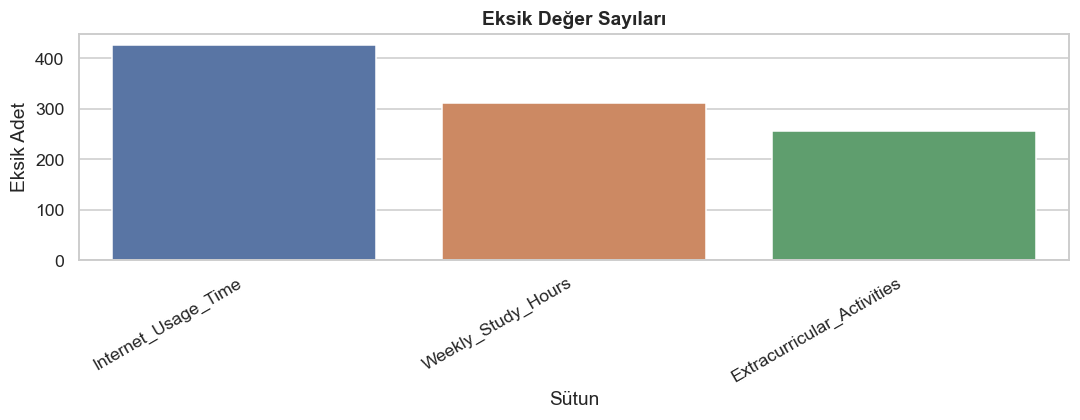

In [52]:
# Eksik veri analizi
missing = df_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Eksik değer sayıları (sadece >0 olanlar):")
display(missing)

plt.figure(figsize=(10, 4))
if len(missing) == 0:
    plt.text(0.5, 0.5, "Eksik değer yok", ha="center", va="center")
    plt.axis("off")
else:
    ax = sns.barplot(x=missing.index, y=missing.values, palette="deep")
    ax.set_title("Eksik Değer Sayıları")
    ax.set_xlabel("Sütun")
    ax.set_ylabel("Eksik Adet")
    plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [53]:
# Mantıksal tutarsızlık tanıları (EDA)

total_records = len(df_raw)

# Negatif mesafe
neg_dist_count = (df_raw["Distance_to_School"] < 0).sum() if "Distance_to_School" in df_raw.columns else 0

# Aşırı uyku (EDA tanısı: 24+ üstü imkansız)
sleep_over_24 = (df_raw["Sleep_Hours"] > 24).sum() if "Sleep_Hours" in df_raw.columns else 0

# Exam_Score IQR tanısı
if "Exam_Score" in df_raw.columns:
    q1 = df_raw["Exam_Score"].quantile(0.25)
    q3 = df_raw["Exam_Score"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers = df_raw[(df_raw["Exam_Score"] < lower) | (df_raw["Exam_Score"] > upper)]
    iqr_outlier_count = len(iqr_outliers)
else:
    lower = upper = np.nan
    iqr_outlier_count = 0

print("EDA tanı özeti:")
print(f"- Negatif Distance_to_School: {neg_dist_count} ({neg_dist_count/total_records*100:.2f}%)")
print(f"- Sleep_Hours > 24: {sleep_over_24} ({sleep_over_24/total_records*100:.2f}%)")
print(f"- Exam_Score IQR aykırı: {iqr_outlier_count} ({iqr_outlier_count/total_records*100:.2f}%)")
print(f"  IQR alt/üst sınır: [{lower:.2f}, {upper:.2f}]")

EDA tanı özeti:
- Negatif Distance_to_School: 218 (2.18%)
- Sleep_Hours > 24: 143 (1.43%)
- Exam_Score IQR aykırı: 22 (0.22%)
  IQR alt/üst sınır: [24.35, 83.00]


### Adım 1 ek görseller

Bu bölüm, EDA görsellerini tamamlar:
- Hedef dağılımı (`Exam_Score`) histogram + boxplot
- Korelasyon ısı haritası (sayısallar)
- `Exam_Score` ile korelasyon sıralaması (bar)
- Çok değişkenli görseller (jointplot, stres seviyesine göre renkli scatter)
- Kategorik dağılım (`Parent_Education_Level`)
- Yaşam tarzı pivot görseli
- Segmentasyon: en başarılı %10 vs en başarısız %10

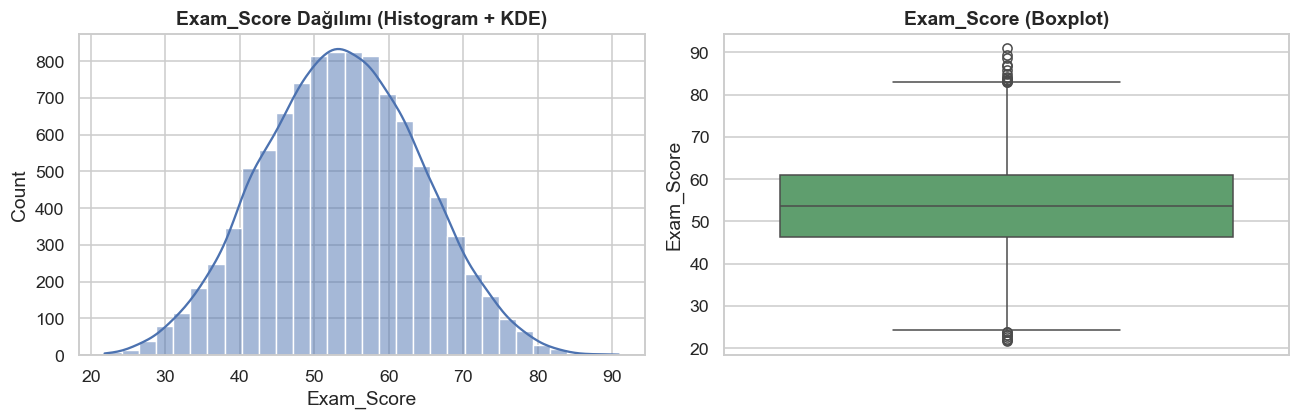

In [54]:
# 1) Hedef değişken dağılımı: Exam_Score

if "Exam_Score" in df_raw.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_raw["Exam_Score"], kde=True, bins=30, ax=axes[0], color="#4C72B0")
    axes[0].set_title("Exam_Score Dağılımı (Histogram + KDE)")
    axes[0].set_xlabel("Exam_Score")

    sns.boxplot(y=df_raw["Exam_Score"], ax=axes[1], color="#55A868", showfliers=True)
    axes[1].set_title("Exam_Score (Boxplot)")
    axes[1].set_ylabel("Exam_Score")

    plt.tight_layout()
    plt.show()
else:
    print("Exam_Score kolonu bulunamadı.")

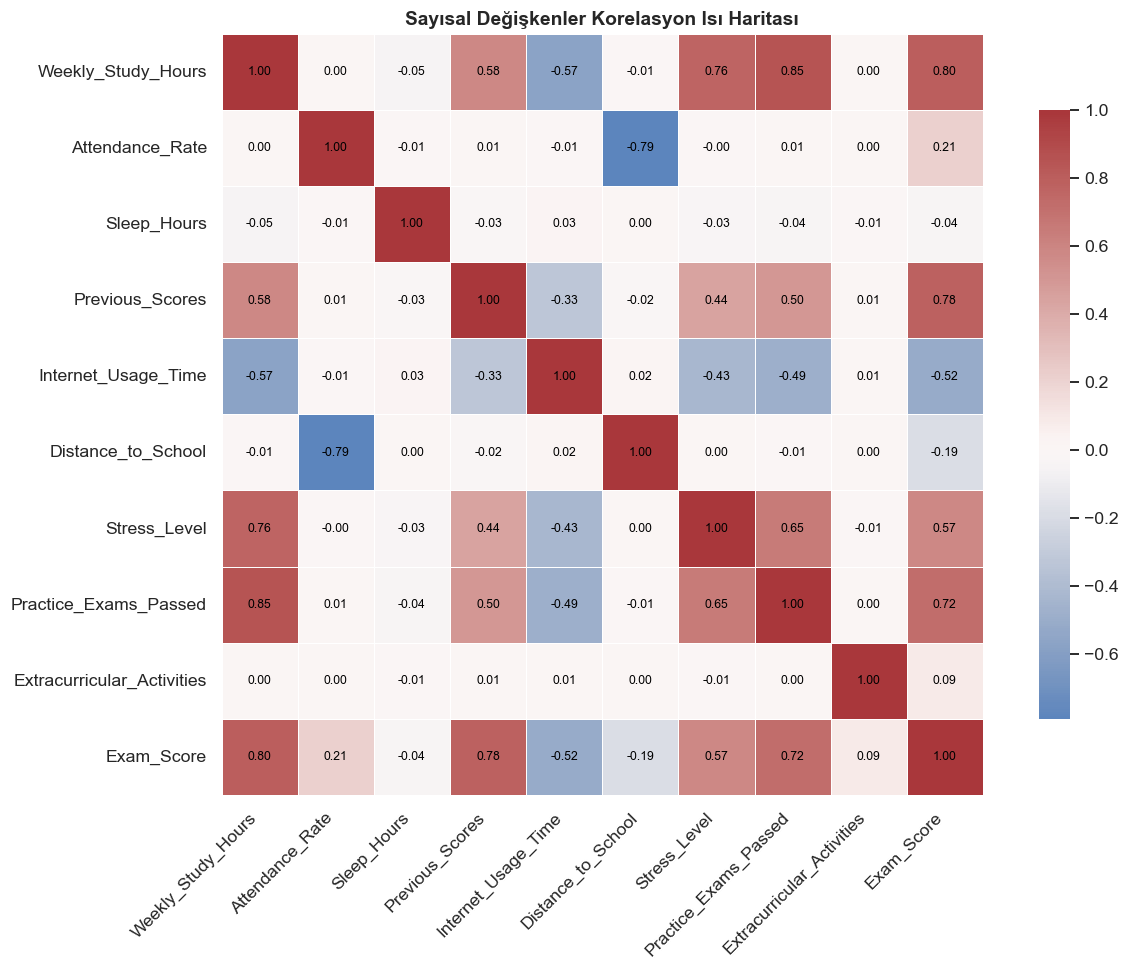

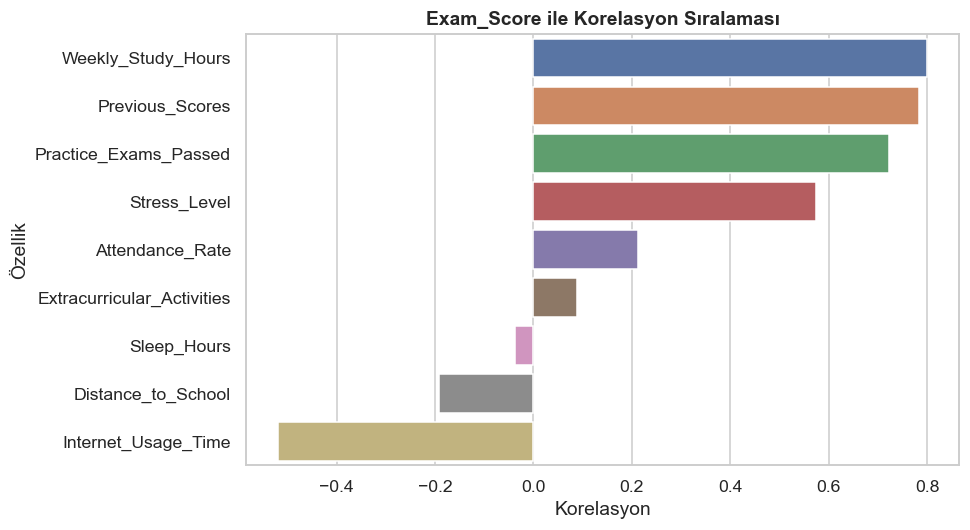

In [55]:
# 2) Korelasyon analizi: full heatmap + Exam_Score korelasyon sıralaması

num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if "Student_ID" in num_cols:
    num_cols.remove("Student_ID")

if len(num_cols) > 1:
    corr = df_raw[num_cols].corr()

    plt.figure(figsize=(12, 9))
    ax = sns.heatmap(
        corr,
        cmap="vlag",
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8, "color": "black"},
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.title("Sayısal Değişkenler Korelasyon Isı Haritası")
    plt.tight_layout()
    plt.show()

    if "Exam_Score" in corr.columns:
        corr_with_target = corr["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)
        plt.figure(figsize=(9, 5))
        sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="deep")
        plt.title("Exam_Score ile Korelasyon Sıralaması")
        plt.xlabel("Korelasyon")
        plt.ylabel("Özellik")
        plt.tight_layout()
        plt.show()
else:
    print("Korelasyon için yeterli sayısal kolon bulunamadı.")

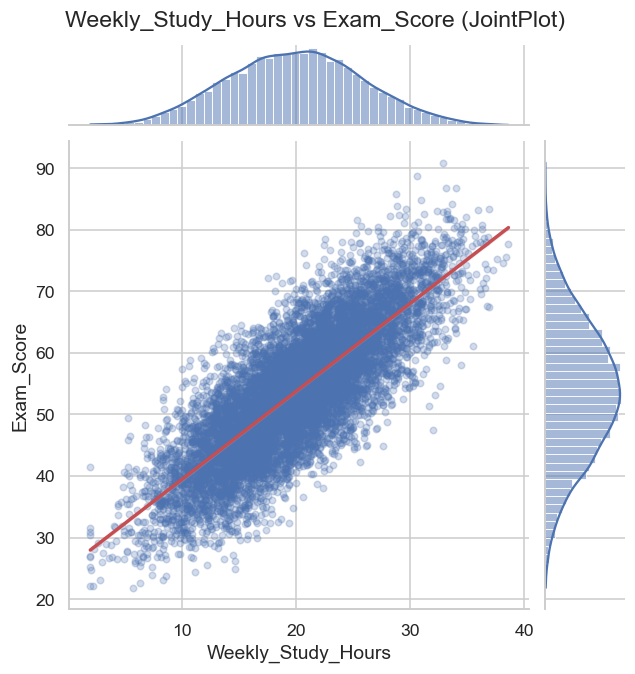

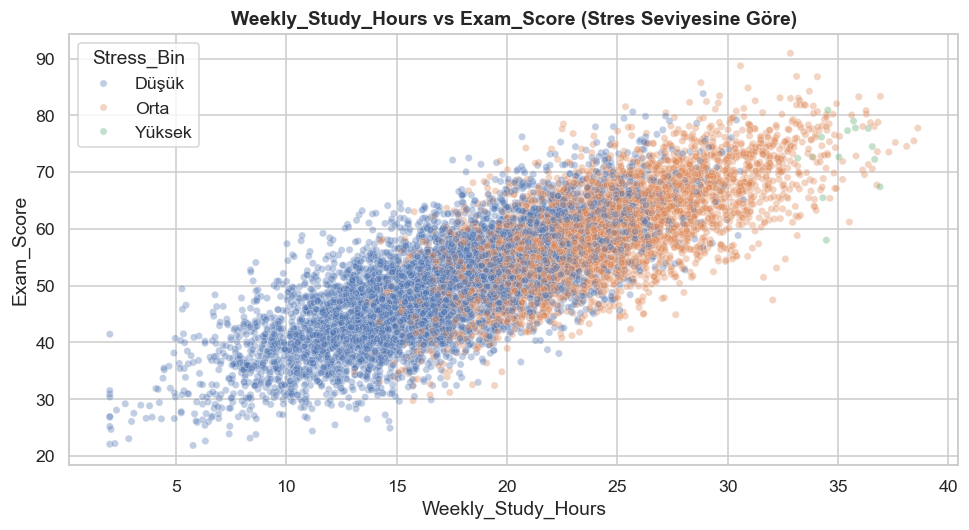

In [56]:
# 3) Çok değişkenli görseller

# A) Jointplot: Weekly_Study_Hours vs Exam_Score
if all(c in df_raw.columns for c in ["Weekly_Study_Hours", "Exam_Score"]):
    sns.jointplot(
        data=df_raw,
        x="Weekly_Study_Hours",
        y="Exam_Score",
        kind="reg",
        height=6,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "#C44E52"},
    )
    plt.suptitle("Weekly_Study_Hours vs Exam_Score (JointPlot)", y=1.02)
    plt.show()

# B) Hue scatter: Stress_Level kategorisi ile
if all(c in df_raw.columns for c in ["Weekly_Study_Hours", "Exam_Score", "Stress_Level"]):
    tmp = df_raw[["Weekly_Study_Hours", "Exam_Score", "Stress_Level"]].copy()
    # Stresi 3 gruba ayır
    tmp["Stress_Bin"] = pd.cut(tmp["Stress_Level"], bins=[-np.inf, 3.5, 7.0, np.inf], labels=["Düşük", "Orta", "Yüksek"])

    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=tmp,
        x="Weekly_Study_Hours",
        y="Exam_Score",
        hue="Stress_Bin",
        palette="deep",
        alpha=0.35,
        s=22,
    )
    plt.title("Weekly_Study_Hours vs Exam_Score (Stres Seviyesine Göre)")
    plt.tight_layout()
    plt.show()

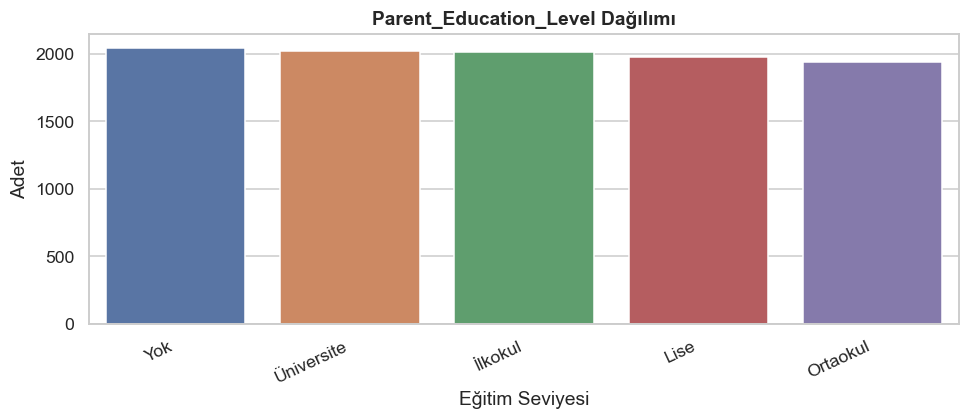

In [57]:
# 4) Parent_Education_Level dağılımı (kategorik görsel)

if "Parent_Education_Level" in df_raw.columns:
    plt.figure(figsize=(9, 4))
    order = df_raw["Parent_Education_Level"].value_counts().index
    sns.countplot(data=df_raw, x="Parent_Education_Level", order=order, palette="deep")
    plt.title("Parent_Education_Level Dağılımı")
    plt.xlabel("Eğitim Seviyesi")
    plt.ylabel("Adet")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

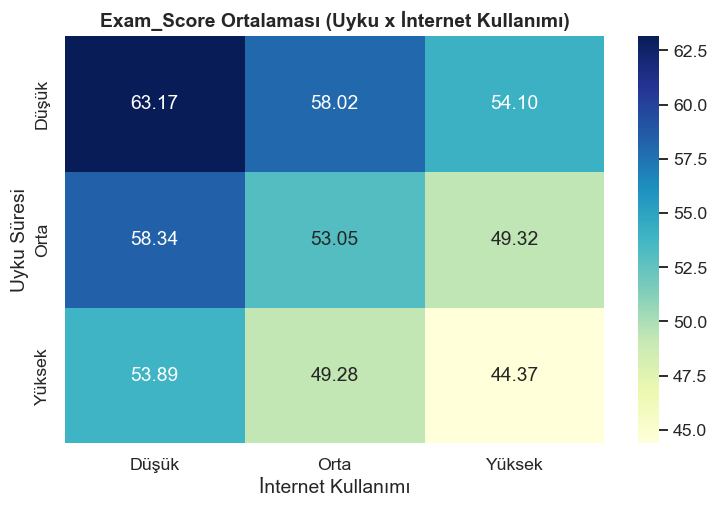

In [58]:
# 5) Yaşam tarzı / alışkanlık analizi: 3x3 pivot (örnek)
# Mantık: Internet_Usage_Time ve Sleep_Hours'ı düşük/orta/yüksek böl ve Exam_Score ortalamasını pivot ile göster.

if all(c in df_raw.columns for c in ["Internet_Usage_Time", "Sleep_Hours", "Exam_Score"]):
    tmp = df_raw[["Internet_Usage_Time", "Sleep_Hours", "Exam_Score"]].dropna().copy()

    tmp["Internet_Bin"] = pd.qcut(tmp["Internet_Usage_Time"], q=3, labels=["Düşük", "Orta", "Yüksek"])
    tmp["Sleep_Bin"] = pd.qcut(tmp["Sleep_Hours"], q=3, labels=["Düşük", "Orta", "Yüksek"])

    pivot = tmp.pivot_table(index="Sleep_Bin", columns="Internet_Bin", values="Exam_Score", aggfunc="mean")

    plt.figure(figsize=(7, 4.8))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title("Exam_Score Ortalaması (Uyku x İnternet Kullanımı)")
    plt.xlabel("İnternet Kullanımı")
    plt.ylabel("Uyku Süresi")
    plt.tight_layout()
    plt.show()

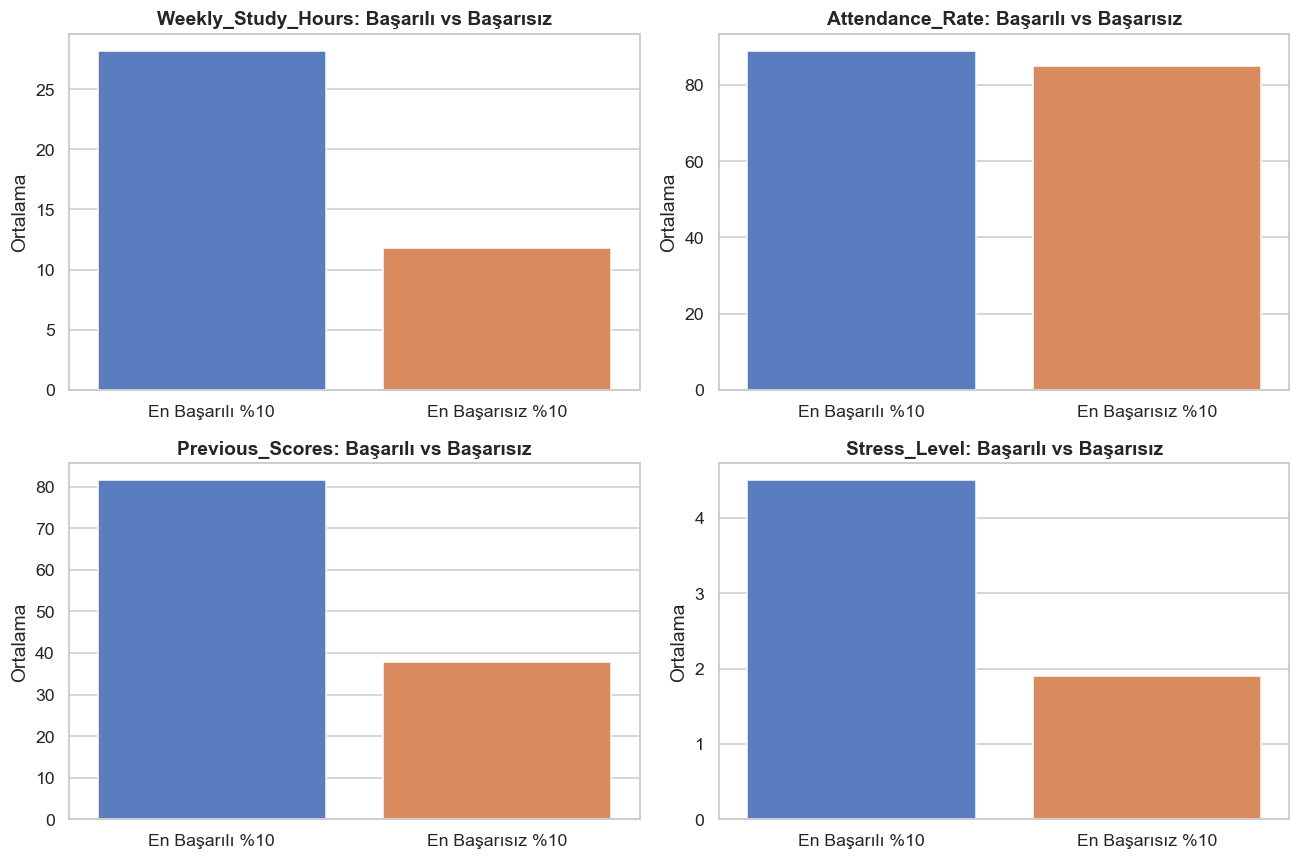

In [59]:
# 6) Segmentasyon: En başarılı %10 vs en başarısız %10

if "Exam_Score" in df_raw.columns:
    n = max(1, int(len(df_raw) * 0.10))
    top = df_raw.nlargest(n, "Exam_Score").copy()
    bottom = df_raw.nsmallest(n, "Exam_Score").copy()
    top["Group"] = "En Başarılı %10"
    bottom["Group"] = "En Başarısız %10"
    seg = pd.concat([top, bottom], ignore_index=True)

    compare_features = [c for c in ["Weekly_Study_Hours", "Attendance_Rate", "Previous_Scores", "Stress_Level"] if c in seg.columns]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for i, col in enumerate(compare_features[:4]):
        sns.barplot(data=seg, x="Group", y=col, ax=axes[i], palette="muted", errorbar=None)
        axes[i].set_title(f"{col}: Başarılı vs Başarısız")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Ortalama")

    # Kullanılmayan subplot varsa kapat
    for j in range(len(compare_features), 4):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## Adım 2: Veri Temizleme ve Ön İşleme

Girdi: `dataset/student_performance.csv`

Bu adımda:
- Eksik değerleri medyan ile dolduracağız
- Mantıksız değerleri mantıklı sınırlara çekeceğiz
- `Exam_Score` için IQR winsorize (kırpma) uygulayacağız (satır silmeden)
- Tip/yuvarlama düzenlemeleri yapacağız

Çıktı: `dataset/student_performance_cleaned.csv`

In [60]:
# Adım 2 boyunca "buyken → bu oldu" göstermek için küçük yardımcılar
# (Bu bölüm, anlatımı kolaylaştırmak için aşağıda küçük bloklara bölündü.)

df = df_raw.copy()

def _num_summary(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce")
    return {
        "min": float(s.min()),
        "q1": float(s.quantile(0.25)),
        "median": float(s.median()),
        "q3": float(s.quantile(0.75)),
        "max": float(s.max()),
    }


def _log_step(
    step: str,
    df_before: pd.DataFrame,
    df_after: pd.DataFrame,
    affected_mask=None,
    columns=None,
    notes: str = "",
):
    columns = columns or []
    changed_rows = None
    if affected_mask is not None:
        try:
            changed_rows = int(pd.Series(affected_mask).fillna(False).sum())
        except Exception:
            changed_rows = None

    entry = {
        "step": step,
        "rows_before": int(len(df_before)),
        "rows_after": int(len(df_after)),
        "total_nan_before": int(df_before.isna().sum().sum()),
        "total_nan_after": int(df_after.isna().sum().sum()),
        "changed_rows": changed_rows,
        "columns": ", ".join([c for c in columns if c in df_before.columns or c in df_after.columns]),
        "notes": notes,
    }

    for c in columns:
        if c in df_before.columns and c in df_after.columns and pd.api.types.is_numeric_dtype(df_before[c]):
            b = _num_summary(df_before[c])
            a = _num_summary(df_after[c])
            entry[f"{c}_min_before"] = b["min"]
            entry[f"{c}_min_after"] = a["min"]
            entry[f"{c}_median_before"] = b["median"]
            entry[f"{c}_median_after"] = a["median"]
            entry[f"{c}_max_before"] = b["max"]
            entry[f"{c}_max_after"] = a["max"]

    step2_log.append(entry)


def _preview_change(df_before, df_after, cols, mask, title, n=5):
    """mask: df_before üzerinde boolean maske. cols: gösterilecek kolonlar."""
    cols = [c for c in cols if c in df_before.columns]
    if len(cols) == 0:
        return

    idx = df_before.index[mask]
    print(f"\n{title}")
    print(f"- etkilenen satır: {len(idx)}")

    if len(idx) == 0:
        return

    sample_idx = idx[:n]
    before_view = df_before.loc[sample_idx, cols].copy()
    after_view = df_after.loc[sample_idx, cols].copy()

    before_view.columns = [f"{c}_before" for c in before_view.columns]
    after_view.columns = [f"{c}_after" for c in after_view.columns]

    display(pd.concat([before_view, after_view], axis=1))


def _summary_minmax(df_before, df_after, col, title):
    if col not in df_before.columns:
        return
    print(f"\n{title}")
    print(f"- {col} min/max önce:  {df_before[col].min():.4f} / {df_before[col].max():.4f}")
    print(f"- {col} min/max sonra: {df_after[col].min():.4f} / {df_after[col].max():.4f}")


# Adım 2 rapor biriktirici (sunumda 'ne değişti?' cevabı)
step2_log = []
_log_step(
    step="2.0 Başlangıç",
    df_before=df_raw,
    df_after=df,
    affected_mask=None,
    columns=["Exam_Score", "Sleep_Hours", "Distance_to_School"],
    notes="Ham veriden temizlik adımına geçiş",
)


### 2.1 Eksik değer doldurma (medyan / mode)

Bu adımda eksik değerleri sayısal kolonlarda **medyan**, kategorik kolonlarda **mode** ile dolduruyoruz. Aşağıdaki çıktı, etkilenen satırlardan birkaç örnekte **önce/sonra** karşılaştırması verir.

In [61]:
before = df.copy()
missing_cols = df.columns[df.isna().any()].tolist()
for col in missing_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

after = df.copy()
missing_mask = before.isna().any(axis=1)
_preview_change(before, after, missing_cols, missing_mask, "2.1 Eksik değer doldurma (medyan)")
print(f"- toplam NaN önce: {int(before.isna().sum().sum())}")
print(f"- toplam NaN sonra: {int(after.isna().sum().sum())}")

_log_step(
    step="2.1 Eksik değer doldurma",
    df_before=before,
    df_after=after,
    affected_mask=missing_mask,
    columns=missing_cols + ["Exam_Score"],
    notes="Sayısal: medyan, kategorik: mode",
)



2.1 Eksik değer doldurma (medyan)
- etkilenen satır: 966


,Weekly_Study_Hours_before,Internet_Usage_Time_before,Extracurricular_Activities_before,Weekly_Study_Hours_after,Internet_Usage_Time_after,Extracurricular_Activities_after
2,NaN,8.555020,15.628297,20.001977,8.555020,15.628297
3,NaN,6.908978,1.451629,20.001977,6.908978,1.451629
11,18.69212,9.000000,NaN,18.692120,9.000000,9.969654
35,NaN,3.635155,15.352285,20.001977,3.635155,15.352285
46,NaN,7.069582,6.716795,20.001977,7.069582,6.716795


- toplam NaN önce: 995
- toplam NaN sonra: 0


### 2.2 Tip dönüşümleri

Bu adımda bazı kolonların tipini modelleme/analiz için daha uygun hale getiriyoruz (örn. `Student_ID` string, ebeveyn eğitim seviyesi kategori).

In [62]:
before = df.copy()
if "Student_ID" in df.columns:
    df["Student_ID"] = df["Student_ID"].astype(str)
if "Parent_Education_Level" in df.columns:
    df["Parent_Education_Level"] = df["Parent_Education_Level"].astype("category")

after = df.copy()
print("\n2.2 Tip dönüşümleri")
if "Student_ID" in df.columns:
    print("- Student_ID dtype:", before["Student_ID"].dtype, "->", after["Student_ID"].dtype)
if "Parent_Education_Level" in df.columns:
    print("- Parent_Education_Level dtype:", before["Parent_Education_Level"].dtype, "->", after["Parent_Education_Level"].dtype)


2.2 Tip dönüşümleri
- Student_ID dtype: int64 -> object
- Parent_Education_Level dtype: object -> category


### 2.3 Mantıksal düzeltmeler

Burada “gerçek hayatta olamayacak/sağlıksız” değerleri düzeltiriz.

- **2.3.1 Mesafe**: negatif değerleri `abs` ile pozitife çeviririz.
- **2.3.2 Uyku**: çok uç değerleri (örn. 18 saat üstü) daha makul bir medyana çekeriz.

In [63]:
# 2.3.1 Mesafe: negatif → abs
if "Distance_to_School" in df.columns:
    before = df.copy()
    neg_mask = before["Distance_to_School"] < 0
    df["Distance_to_School"] = df["Distance_to_School"].abs()
    after = df.copy()
    _preview_change(before, after, ["Student_ID", "Distance_to_School"], neg_mask, "2.3.1 Negatif Distance_to_School düzeltmesi (abs)")

    _log_step(
        step="2.3.1 Distance_to_School düzeltme",
        df_before=before,
        df_after=after,
        affected_mask=neg_mask,
        columns=["Distance_to_School"],
        notes="Negatif değerler abs ile düzeltildi",
    )

# 2.3.2 Uyku: > upper_limit → sağlıklı medyan
SLEEP_UPPER_LIMIT = 18.0
if "Sleep_Hours" in df.columns:
    before = df.copy()
    sane_median_sleep = before.loc[before["Sleep_Hours"] <= SLEEP_UPPER_LIMIT, "Sleep_Hours"].median()
    over_mask = before["Sleep_Hours"] > SLEEP_UPPER_LIMIT
    df.loc[over_mask, "Sleep_Hours"] = sane_median_sleep
    after = df.copy()
    _preview_change(before, after, ["Student_ID", "Sleep_Hours"], over_mask, f"2.3.2 Aşırı Sleep_Hours düzeltmesi (> {SLEEP_UPPER_LIMIT})")
    print(f"- kullanılan medyan (Sleep_Hours): {sane_median_sleep:.2f}")

    _log_step(
        step="2.3.2 Sleep_Hours üst sınır",
        df_before=before,
        df_after=after,
        affected_mask=over_mask,
        columns=["Sleep_Hours"],
        notes=f"> {SLEEP_UPPER_LIMIT} değerler medyana çekildi",
    )



2.3.1 Negatif Distance_to_School düzeltmesi (abs)
- etkilenen satır: 218


,Student_ID_before,Distance_to_School_before,Student_ID_after,Distance_to_School_after
41,10041,-5.0,10041,5.0
58,10058,-5.0,10058,5.0
99,10099,-5.0,10099,5.0
151,10151,-5.0,10151,5.0
165,10165,-5.0,10165,5.0



2.3.2 Aşırı Sleep_Hours düzeltmesi (> 18.0)
- etkilenen satır: 143


,Student_ID_before,Sleep_Hours_before,Student_ID_after,Sleep_Hours_after
80,10080,122.6,10080,8.40942
154,10154,134.3,10154,8.40942
160,10160,113.4,10160,8.40942
215,10215,116.0,10215,8.40942
509,10509,129.8,10509,8.40942


- kullanılan medyan (Sleep_Hours): 8.41


### 2.4 `Exam_Score` outlier bastırma (IQR winsorize / clip)

Bu adım, hedef değişken (`Exam_Score`) üzerinde **müdahale** içerdiği için metodolojik olarak dikkat ister.

- **Ne zaman mantıklı?** Ölçüm hatası / hatalı kayıt kaynaklı aşırı uçlar belirginse.
- **Ne zaman kaçınılmalı?** Hedef dağılımını “doğal haliyle” bırakmak istiyorsak (çoğu modelleme akışında tercih edilir).

Aşağıdaki kod, müdahalenin etkisini rapora yazar (kaç satır kırpıldı, min/median/max nasıl değişti) ve böylece “gerekçeli” bir karar vermeyi kolaylaştırır.


In [64]:
if "Exam_Score" in df.columns:
    before = df.copy()

    q1 = before["Exam_Score"].quantile(0.25)
    q3 = before["Exam_Score"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    out_mask = (before["Exam_Score"] < lower) | (before["Exam_Score"] > upper)
    df["Exam_Score"] = df["Exam_Score"].clip(lower=lower, upper=upper)

    after = df.copy()

    clipped_n = int(pd.Series(out_mask).sum())

    print("\n2.4 Exam_Score IQR winsorize (clip)")
    print(f"- alt/üst sınır: [{lower:.2f}, {upper:.2f}]")
    print(f"- kırpılan satır sayısı: {clipped_n}")
    _preview_change(before, after, ["Student_ID", "Exam_Score"], out_mask, "- IQR dışı örnekler (önce/sonra)")
    _summary_minmax(before, after, "Exam_Score", "- min/max değişimi")

    _log_step(
        step="2.4 Exam_Score winsorize",
        df_before=before,
        df_after=after,
        affected_mask=out_mask,
        columns=["Exam_Score"],
        notes=f"IQR clip uygulandı; bounds=[{lower:.2f},{upper:.2f}], clipped_rows={clipped_n}",
    )



2.4 Exam_Score IQR winsorize (clip)
- alt/üst sınır: [24.35, 83.00]
- kırpılan satır sayısı: 22

- IQR dışı örnekler (önce/sonra)
- etkilenen satır: 22


,Student_ID_before,Exam_Score_before,Student_ID_after,Exam_Score_after
1043,11043,22.07,11043,24.34625
1592,11592,21.84,11592,24.34625
2227,12227,23.88,12227,24.34625
2270,12270,83.42,12270,82.99625
2734,12734,85.74,12734,82.99625



- min/max değişimi
- Exam_Score min/max önce:  21.8400 / 90.9100
- Exam_Score min/max sonra: 24.3463 / 82.9962


### 2.5 Duplicate kontrol

Bu adımda aynı satırın tekrarı varsa kaldırırız ve satır sayısının nasıl değiştiğini raporlarız.

In [65]:
before = df.copy()
before_rows = len(df)
dup_count = int(df.duplicated().sum())
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
after = df.copy()
after_rows = len(df)
print("\n2.5 Duplicate kontrol")
print(f"- satır: {before_rows} -> {after_rows} (duplicate: {dup_count})")

_log_step(
    step="2.5 Duplicate kaldırma",
    df_before=before,
    df_after=after,
    affected_mask=None,
    columns=["Exam_Score"],
    notes=f"duplicate_rows={dup_count}",
)



2.5 Duplicate kontrol
- satır: 10000 -> 10000 (duplicate: 0)


### 2.6 Yuvarlama / hassasiyet standardizasyonu

Bu adımda bazı kolonları “gürültüyü azaltmak” ve raporlamayı tutarlı yapmak için yuvarlarız.

- `Stress_Level`: tam sayıya
- Bazı kolonlar: 1 ondalık
- Bazıları: 2 ondalık

En sonda 5 rastgele satırda **önce/sonra** örnek gösteriyoruz.

In [66]:
before = df.copy()
if "Stress_Level" in df.columns:
    df["Stress_Level"] = df["Stress_Level"].round().astype(int)

cols_1_dec = [c for c in ["Weekly_Study_Hours", "Sleep_Hours", "Internet_Usage_Time", "Extracurricular_Activities"] if c in df.columns]
cols_2_dec = [c for c in ["Attendance_Rate", "Previous_Scores", "Distance_to_School", "Exam_Score"] if c in df.columns]

df[cols_1_dec] = df[cols_1_dec].round(1)
df[cols_2_dec] = df[cols_2_dec].round(2)
after = df.copy()

# Yuvarlama etki ölçümü: herhangi bir sayısal kolonda değer değişti mi?
changed_mask = (before.select_dtypes(include=[np.number]).round(6) != after.select_dtypes(include=[np.number]).round(6)).any(axis=1)

sample_idx = before.sample(n=min(5, len(before)), random_state=RANDOM_STATE).index
cols_show = ["Student_ID", "Stress_Level"] + cols_1_dec + cols_2_dec
cols_show = [c for c in cols_show if c in before.columns]

print("\n2.6 Yuvarlama örnekleri (rastgele 5 satır)")
view_before = before.loc[sample_idx, cols_show].copy()
view_after = after.loc[sample_idx, cols_show].copy()
view_before.columns = [f"{c}_before" for c in view_before.columns]
view_after.columns = [f"{c}_after" for c in view_after.columns]
display(pd.concat([view_before, view_after], axis=1))

_log_step(
    step="2.6 Yuvarlama",
    df_before=before,
    df_after=after,
    affected_mask=changed_mask,
    columns=list(set(cols_1_dec + cols_2_dec + ["Stress_Level"])),
    notes="Ondalık standardizasyonu ve Stress_Level int",
)

print("\nAdım 2 çıktı örneği:")
display(df.head())


2.6 Yuvarlama örnekleri (rastgele 5 satır)


,Student_ID_before,Stress_Level_before,Weekly_Study_Hours_before,Sleep_Hours_before,Internet_Usage_Time_before,Extracurricular_Activities_before,Attendance_Rate_before,Previous_Scores_before,Distance_to_School_before,Exam_Score_before,Student_ID_after,Stress_Level_after,Weekly_Study_Hours_after,Sleep_Hours_after,Internet_Usage_Time_after,Extracurricular_Activities_after,Attendance_Rate_after,Previous_Scores_after,Distance_to_School_after,Exam_Score_after
6252,16252,4.747302,20.001977,8.055728,7.859991,12.843734,79.062226,84.094133,38.370360,61.70,16252,5,20.0,8.1,7.9,12.8,79.06,84.09,38.37,61.70
4684,14684,4.352952,19.294636,8.805271,9.000000,7.484914,79.517226,29.464743,39.681101,39.77,14684,4,19.3,8.8,9.0,7.5,79.52,29.46,39.68,39.77
1731,11731,3.886864,14.221392,7.989546,9.000000,5.179498,80.835119,31.501483,38.704922,33.10,11731,4,14.2,8.0,9.0,5.2,80.84,31.50,38.70,33.10
4742,14742,3.913826,19.296872,8.087653,8.959852,7.458528,87.766876,71.338363,10.726105,48.82,14742,4,19.3,8.1,9.0,7.5,87.77,71.34,10.73,48.82
4521,14521,4.697678,29.097143,7.117704,7.625533,19.314075,85.967605,77.419371,33.290487,68.07,14521,5,29.1,7.1,7.6,19.3,85.97,77.42,33.29,68.07



Adım 2 çıktı örneği:


,Student_ID,Weekly_Study_Hours,Attendance_Rate,Sleep_Hours,Previous_Scores,Internet_Usage_Time,Parent_Education_Level,Distance_to_School,Stress_Level,Practice_Exams_Passed,Extracurricular_Activities,Exam_Score
0,10000,28.5,92.43,6.9,88.87,8.2,Lise,2.02,6,11,5.8,62.74
1,10001,18.2,84.94,8.8,53.51,8.0,Üniversite,35.22,1,9,19.2,54.92
2,10002,20.0,91.22,9.6,32.50,8.6,Ortaokul,12.94,3,6,15.6,42.86
3,10003,20.0,94.81,7.4,63.86,6.9,Üniversite,5.59,5,13,1.5,63.47
4,10004,23.8,83.93,8.4,59.74,7.2,Üniversite,19.00,4,13,19.1,57.80


### Adım 2 Temizlik Raporu 

Aşağıdaki tablo, Adım 2 boyunca hangi müdahalenin **kaç satırı etkilediğini**, toplam **NaN sayısının nasıl değiştiğini** ve seçili sayısal kolonlarda (özellikle `Exam_Score`) özet istatistiklerin nasıl değiştiğini gösterir.

In [67]:
step2_report = pd.DataFrame(step2_log)

# Daha okunur bir kolon sırası
base_cols = [
    "step",
    "rows_before",
    "rows_after",
    "changed_rows",
    "total_nan_before",
    "total_nan_after",
    "columns",
    "notes",
]
other_cols = [c for c in step2_report.columns if c not in base_cols]
step2_report = step2_report[base_cols + other_cols]

display(step2_report)

# Hızlı özet: başlangıçtan son adıma NaN ve satır farkı
try:
    start = step2_report.iloc[0]
    end = step2_report.iloc[-1]
    print("\nAdım 2 toplam özet")
    print(f"- satır: {int(start['rows_before'])} -> {int(end['rows_after'])}")
    print(f"- toplam NaN: {int(start['total_nan_before'])} -> {int(end['total_nan_after'])}")
except Exception:
    pass

,step,rows_before,rows_after,changed_rows,total_nan_before,total_nan_after,columns,notes,Exam_Score_min_before,Exam_Score_min_after,...,Stress_Level_median_before,Stress_Level_median_after,Stress_Level_max_before,Stress_Level_max_after,Attendance_Rate_min_before,Attendance_Rate_min_after,Attendance_Rate_median_before,Attendance_Rate_median_after,Attendance_Rate_max_before,Attendance_Rate_max_after
0,2.0 Başlangıç,10000,10000,NaN,995,995,"Exam_Score, Sleep_Hours, Distance_to_School",Ham veriden temizlik adımına geçiş,21.84000,21.84000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.1 Eksik değer doldurma,10000,10000,966.0,995,0,"Weekly_Study_Hours, Internet_Usage_Time, Extra...","Sayısal: medyan, kategorik: mode",21.84000,21.84000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.3.1 Distance_to_School düzeltme,10000,10000,218.0,0,0,Distance_to_School,Negatif değerler abs ile düzeltildi,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.3.2 Sleep_Hours üst sınır,10000,10000,143.0,0,0,Sleep_Hours,> 18.0 değerler medyana çekildi,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.4 Exam_Score winsorize,10000,10000,22.0,0,0,Exam_Score,"IQR clip uygulandı; bounds=[24.35,83.00], clip...",21.84000,24.34625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2.5 Duplicate kaldırma,10000,10000,NaN,0,0,Exam_Score,duplicate_rows=0,24.34625,24.34625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2.6 Yuvarlama,10000,10000,10000.0,0,0,"Weekly_Study_Hours, Extracurricular_Activities...",Ondalık standardizasyonu ve Stress_Level int,24.34625,24.35000,...,3.126869,3.0,7.816497,8.0,74.126225,74.13,86.904385,86.905,99.65489,99.65



Adım 2 toplam özet
- satır: 10000 -> 10000
- toplam NaN: 995 -> 0


### Adım 2 görsel doğrulama (önce/sonra)

Aşağıdaki grafikler, temizlik müdahalelerinin dağılımlar üzerinde nasıl bir etkisi olduğunu gösterir:
- `Exam_Score`: IQR winsorize (clip)
- `Sleep_Hours`: üst sınır düzeltmesi
- `Distance_to_School`: negatiften abs'e dönüşüm

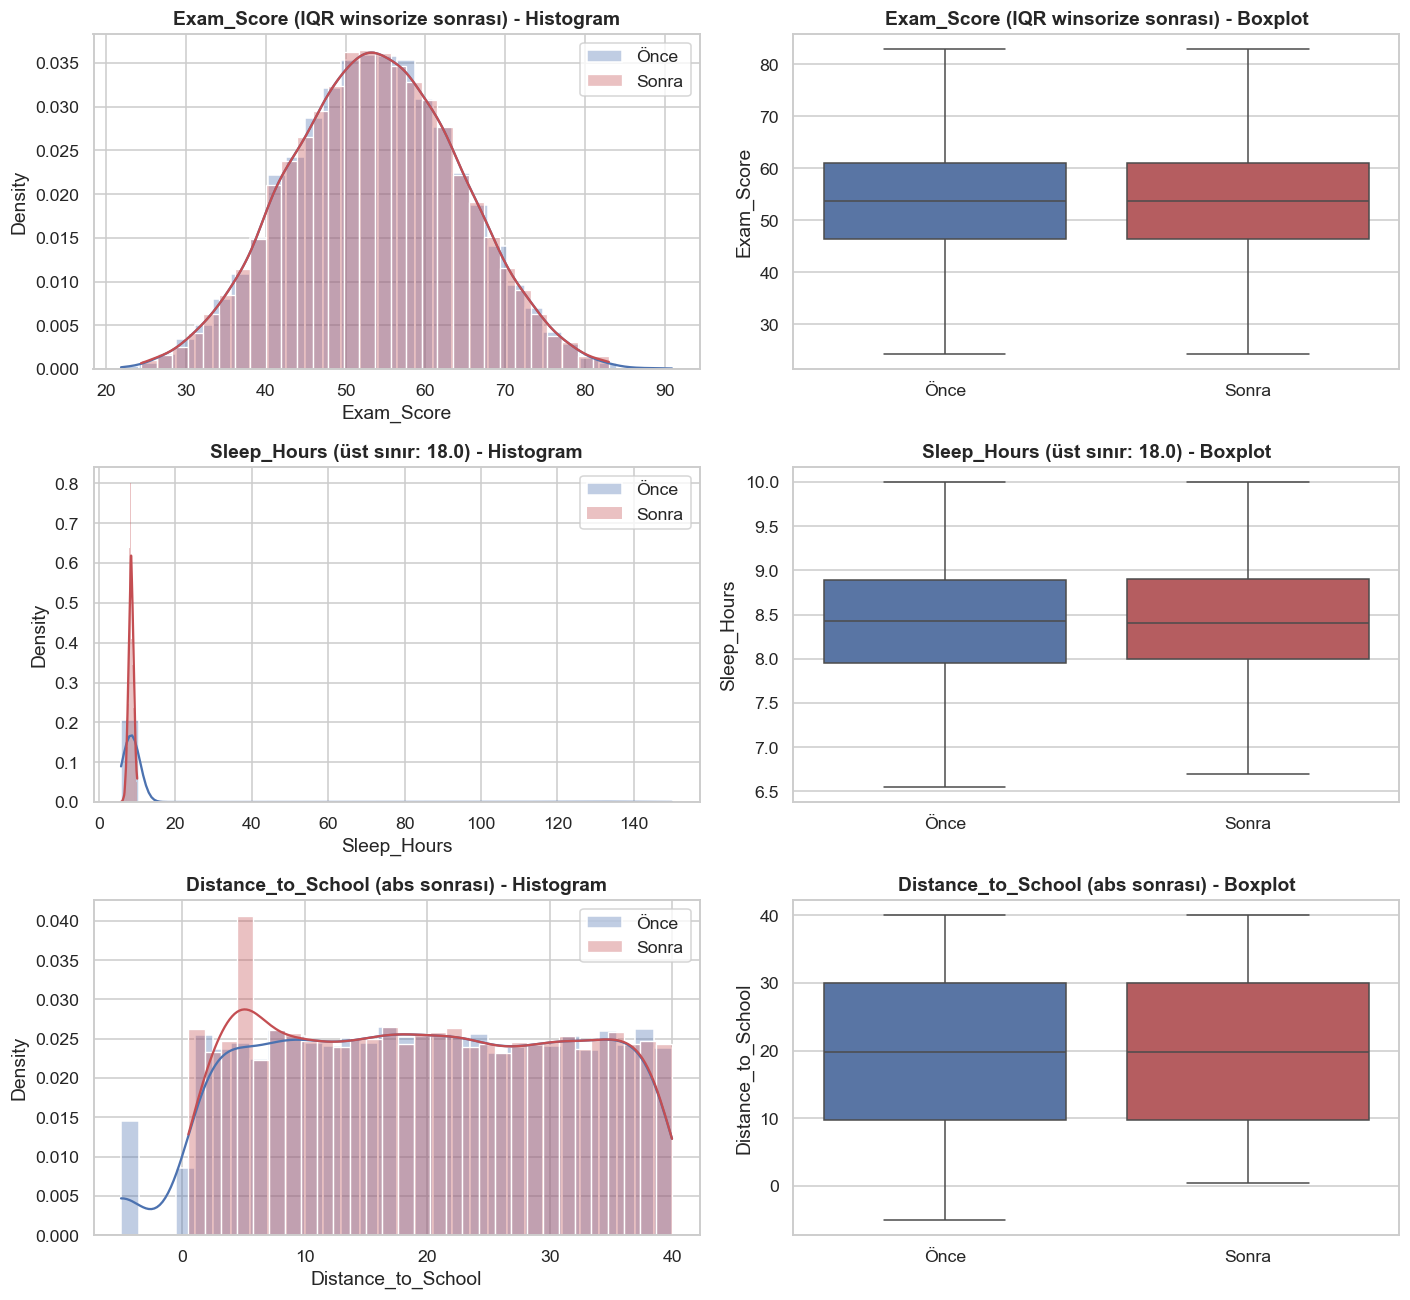

In [68]:
# Önce/sonra karşılaştırmaları için: before = df_raw (ham), after = df (temiz)
# Not: Ham veride NaN olabilir; grafiklerde otomatik düşürülür.

before_df = df_raw.copy()
after_df = df.copy()

vars_to_plot = [
    ("Exam_Score", "Exam_Score (IQR winsorize sonrası)"),
    ("Sleep_Hours", f"Sleep_Hours (üst sınır: {SLEEP_UPPER_LIMIT})"),
    ("Distance_to_School", "Distance_to_School (abs sonrası)"),
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))

for i, (col, title) in enumerate(vars_to_plot):
    if col not in before_df.columns or col not in after_df.columns:
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        continue

    b = before_df[col].dropna()
    a = after_df[col].dropna()

    # Histogram (önce/sonra)
    ax_h = axes[i, 0]
    sns.histplot(b, ax=ax_h, color="#4C72B0", stat="density", kde=True, bins=30, alpha=0.35, label="Önce")
    sns.histplot(a, ax=ax_h, color="#C44E52", stat="density", kde=True, bins=30, alpha=0.35, label="Sonra")
    ax_h.set_title(f"{title} - Histogram")
    ax_h.set_xlabel(col)
    ax_h.legend()

    # Boxplot (önce/sonra)
    ax_b = axes[i, 1]
    plot_df = pd.DataFrame({
        "value": pd.concat([b, a], ignore_index=True),
        "stage": (["Önce"] * len(b)) + (["Sonra"] * len(a)),
    })
    sns.boxplot(data=plot_df, x="stage", y="value", ax=ax_b, palette=["#4C72B0", "#C44E52"], showfliers=False)
    ax_b.set_title(f"{title} - Boxplot")
    ax_b.set_xlabel("")
    ax_b.set_ylabel(col)

plt.tight_layout()
plt.show()

In [69]:
# 2.7 Adım 2 kalite kontrolleri

numeric_df = df.select_dtypes(include=[np.number])

checks = {
    "no_missing": int(df.isna().sum().sum()) == 0,
    "finite_numeric": np.isfinite(numeric_df.to_numpy()).all(),
    "distance_non_negative": (df["Distance_to_School"] >= 0).all() if "Distance_to_School" in df.columns else True,
    "sleep_within_limit": (df["Sleep_Hours"] <= SLEEP_UPPER_LIMIT).all() if "Sleep_Hours" in df.columns else True,
}

display(pd.Series(checks, name="Step2_checks"))
assert all(checks.values()), "Adım 2 kontrollerinden en az biri başarısız oldu."

CLEAN_PATH = "dataset/student_performance_cleaned.csv"
df.to_csv(CLEAN_PATH, index=False)
print(f"Temiz veri kaydedildi: {CLEAN_PATH}")

no_missing               True
finite_numeric           True
distance_non_negative    True
sleep_within_limit       True
Name: Step2_checks, dtype: bool

Temiz veri kaydedildi: dataset/student_performance_cleaned.csv


## Adım 3: Özellik Mühendisliği ve Özellik Seçimi

Girdi: `dataset/student_performance_cleaned.csv`

Bu adımda:
- Yeni özellikler türeteceğiz (hedefi kullanmadan)
- (İsteğe bağlı) log dönüşümlerini görsel olarak değerlendireceğiz
- Kategorik veriyi encoding ile sayısala çevireceğiz
- Korelasyon + MI ile eleme önerisi üreteceğiz

Çıktı: `dataset/student_performance_features.csv`

In [70]:
df = pd.read_csv(CLEAN_PATH)
print(f"Temiz veri yüklendi: {CLEAN_PATH}")
print(f"Shape: {df.shape}")

# Yapısal kontroller
required_cols = ["Exam_Score", "Student_ID"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Beklenen kolon bulunamadı: {c}")

print("Eksik değer kontrolü (toplam NaN):", int(df.isna().sum().sum()))
display(df.head())

Temiz veri yüklendi: dataset/student_performance_cleaned.csv
Shape: (10000, 12)
Eksik değer kontrolü (toplam NaN): 0


,Student_ID,Weekly_Study_Hours,Attendance_Rate,Sleep_Hours,Previous_Scores,Internet_Usage_Time,Parent_Education_Level,Distance_to_School,Stress_Level,Practice_Exams_Passed,Extracurricular_Activities,Exam_Score
0,10000,28.5,92.43,6.9,88.87,8.2,Lise,2.02,6,11,5.8,62.74
1,10001,18.2,84.94,8.8,53.51,8.0,Üniversite,35.22,1,9,19.2,54.92
2,10002,20.0,91.22,9.6,32.50,8.6,Ortaokul,12.94,3,6,15.6,42.86
3,10003,20.0,94.81,7.4,63.86,6.9,Üniversite,5.59,5,13,1.5,63.47
4,10004,23.8,83.93,8.4,59.74,7.2,Üniversite,19.00,4,13,19.1,57.80


In [71]:
# Bölüm B: Feature Engineering (y hedefini kullanmadan)

# Sıfıra bölünmeyi engellemek için payda +1
if "Weekly_Study_Hours" in df.columns and "Practice_Exams_Passed" in df.columns:
    df["total_study_load"] = df["Weekly_Study_Hours"] + df["Practice_Exams_Passed"]

if "Attendance_Rate" in df.columns and "Weekly_Study_Hours" in df.columns:
    df["attendance_to_study_ratio"] = df["Attendance_Rate"] / (df["Weekly_Study_Hours"] + 1)

if "Stress_Level" in df.columns and "Weekly_Study_Hours" in df.columns:
    df["stress_x_study"] = df["Stress_Level"] * df["Weekly_Study_Hours"]

if "Previous_Scores" in df.columns and "Weekly_Study_Hours" in df.columns:
    df["prev_efficiency"] = df["Previous_Scores"] / (df["Weekly_Study_Hours"] + 1)

new_cols = [c for c in ["total_study_load", "attendance_to_study_ratio", "stress_x_study", "prev_efficiency"] if c in df.columns]
print("Yeni türetilen kolonlar:", new_cols)
display(df[new_cols].head())

# Sayısal değerlerde inf/nan kontrolü (sadece sayısallarda)
num = df.select_dtypes(include=[np.number])
assert np.isfinite(num.to_numpy()).all(), "Sayısal alanlarda inf/-inf var."

Yeni türetilen kolonlar: ['total_study_load', 'attendance_to_study_ratio', 'stress_x_study', 'prev_efficiency']


,total_study_load,attendance_to_study_ratio,stress_x_study,prev_efficiency
0,39.5,3.133220,171.0,3.012542
1,27.2,4.423958,18.2,2.786979
2,26.0,4.343810,60.0,1.547619
3,33.0,4.514762,100.0,3.040952
4,36.8,3.384274,95.2,2.408871


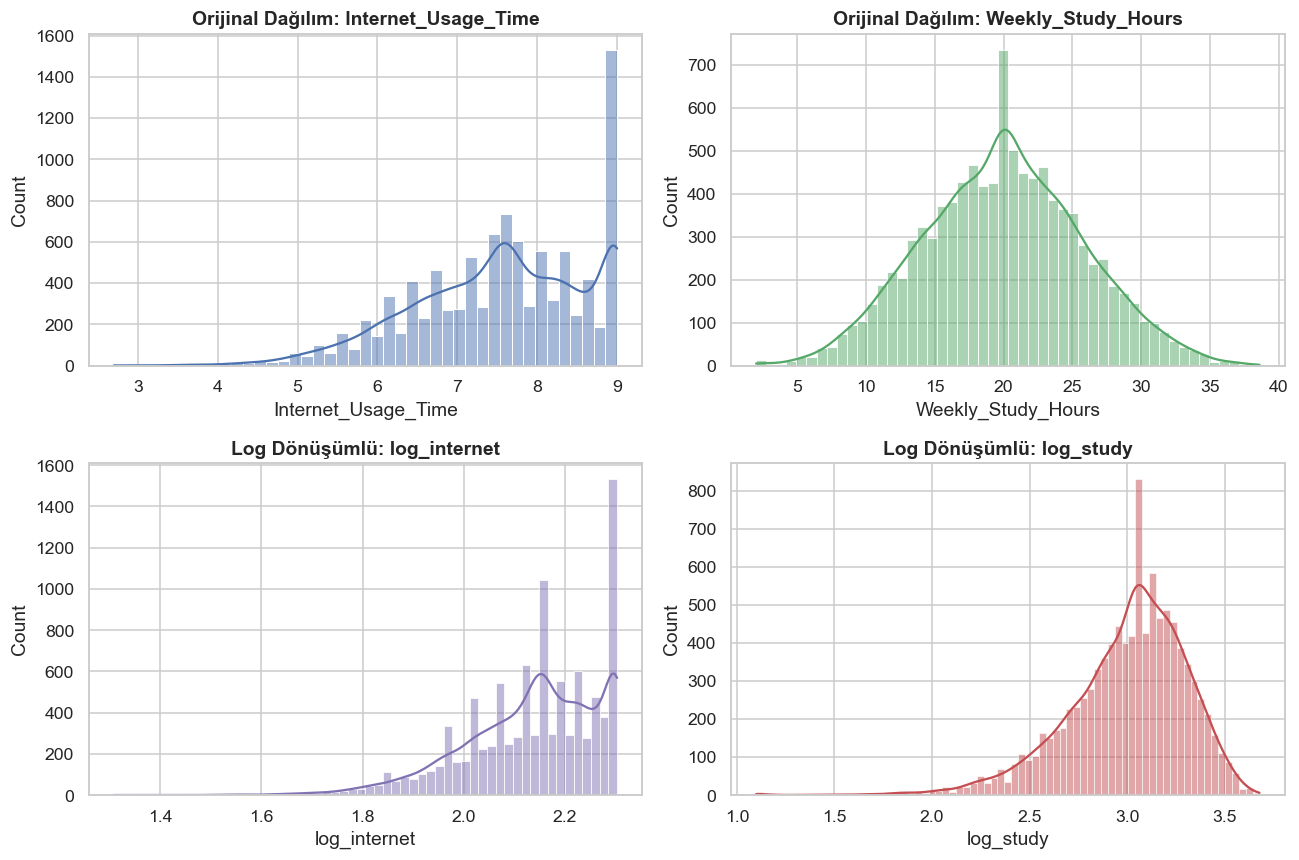

In [72]:
# Bölüm C: Log dönüşümü (değerlendirme amaçlı)

log_targets = [c for c in ["Internet_Usage_Time", "Weekly_Study_Hours"] if c in df.columns]
if len(log_targets) == 2:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.histplot(df[log_targets[0]], kde=True, ax=axes[0, 0], color="#4C72B0")
    axes[0, 0].set_title(f"Orijinal Dağılım: {log_targets[0]}")

    sns.histplot(df[log_targets[1]], kde=True, ax=axes[0, 1], color="#55A868")
    axes[0, 1].set_title(f"Orijinal Dağılım: {log_targets[1]}")

    df["log_internet"] = np.log1p(df[log_targets[0]])
    df["log_study"] = np.log1p(df[log_targets[1]])

    sns.histplot(df["log_internet"], kde=True, ax=axes[1, 0], color="#8172B3")
    axes[1, 0].set_title("Log Dönüşümlü: log_internet")

    sns.histplot(df["log_study"], kde=True, ax=axes[1, 1], color="#C44E52")
    axes[1, 1].set_title("Log Dönüşümlü: log_study")

    plt.tight_layout()
    plt.show()
else:
    print("Log dönüşümü için gerekli kolonlar bulunamadı.")

In [73]:
# Bölüm D: Encoding

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

if "Parent_Education_Level" in df.columns:
    print("Parent_Education_Level dağılımı:")
    display(df["Parent_Education_Level"].value_counts())

    # 1) Metni normalize et (TR/EN varyantları tek bir kanonik etikete indir)
    edu_norm = (
        df["Parent_Education_Level"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "üniversite": "university",
            "yüksek lisans": "master",
            "doktora": "phd",
            "ilkokul": "primary",
            "ortaokul": "middle school",
            "lise": "high school",
            "yok": "none",
        })
    )

    # 2) Ordinal encoding (sıralı eğitim seviyesi)
    edu_order = ["none", "primary", "middle school", "high school", "college", "university", "bachelor", "master", "phd"]
    ord_enc = OrdinalEncoder(
        categories=[edu_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1,
    )

    df["Parent_Education_Ordinal"] = ord_enc.fit_transform(edu_norm.to_frame()).astype(int)

    # 3) One-hot encoding (kategorik sinyal)
    ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    ohe_arr = ohe.fit_transform(edu_norm.to_frame())
    ohe_cols = [f"PE_{c}" for c in ohe.categories_[0][1:]]
    ohe_df = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df.index)

    df = df.drop(columns=["Parent_Education_Level"])  # orijinal metni kaldır
    df = pd.concat([df, ohe_df], axis=1)

# Geçici log kolonlarını temizle (değerlendirme amaçlıydı)
for c in ["log_internet", "log_study"]:
    if c in df.columns:
        df = df.drop(columns=[c])

print("Encoding sonrası shape:", df.shape)
display(df.head())

Parent_Education_Level dağılımı:


Parent_Education_Level
Yok           2047
Üniversite    2019
İlkokul       2016
Lise          1975
Ortaokul      1943
Name: count, dtype: int64

Encoding sonrası shape: (10000, 20)


,Student_ID,Weekly_Study_Hours,Attendance_Rate,Sleep_Hours,Previous_Scores,Internet_Usage_Time,Distance_to_School,Stress_Level,Practice_Exams_Passed,Extracurricular_Activities,Exam_Score,total_study_load,attendance_to_study_ratio,stress_x_study,prev_efficiency,Parent_Education_Ordinal,PE_i̇lkokul,PE_middle school,PE_none,PE_university
0,10000,28.5,92.43,6.9,88.87,8.2,2.02,6,11,5.8,62.74,39.5,3.133220,171.0,3.012542,3,0.0,0.0,0.0,0.0
1,10001,18.2,84.94,8.8,53.51,8.0,35.22,1,9,19.2,54.92,27.2,4.423958,18.2,2.786979,5,0.0,0.0,0.0,1.0
2,10002,20.0,91.22,9.6,32.50,8.6,12.94,3,6,15.6,42.86,26.0,4.343810,60.0,1.547619,2,0.0,1.0,0.0,0.0
3,10003,20.0,94.81,7.4,63.86,6.9,5.59,5,13,1.5,63.47,33.0,4.514762,100.0,3.040952,5,0.0,0.0,0.0,1.0
4,10004,23.8,83.93,8.4,59.74,7.2,19.00,4,13,19.1,57.80,36.8,3.384274,95.2,2.408871,5,0.0,0.0,0.0,1.0


In [74]:
# Bölüm E: Feature Selection (Pearson + MI)
# Bu bölüm sunumda rahat anlatılabilsin diye küçük parçalara ayrılmıştır.


### E.1 Özellik matrisi (`X`) ve hedef (`y`)

Bu adımda sayısal değişkenlerden feature matrisi `X` oluşturup hedef değişkeni `y = Exam_Score` olarak ayırıyoruz.

In [75]:
from sklearn.feature_selection import mutual_info_regression

X = df.select_dtypes(include=[np.number]).drop(columns=["Student_ID", "Exam_Score"], errors="ignore")
y = df["Exam_Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (10000, 18)
y shape: (10000,)


,Weekly_Study_Hours,Attendance_Rate,Sleep_Hours,Previous_Scores,Internet_Usage_Time,Distance_to_School,Stress_Level,Practice_Exams_Passed,Extracurricular_Activities,total_study_load,attendance_to_study_ratio,stress_x_study,prev_efficiency,Parent_Education_Ordinal,PE_i̇lkokul,PE_middle school,PE_none,PE_university
0,28.5,92.43,6.9,88.87,8.2,2.02,6,11,5.8,39.5,3.133220,171.0,3.012542,3,0.0,0.0,0.0,0.0
1,18.2,84.94,8.8,53.51,8.0,35.22,1,9,19.2,27.2,4.423958,18.2,2.786979,5,0.0,0.0,0.0,1.0
2,20.0,91.22,9.6,32.50,8.6,12.94,3,6,15.6,26.0,4.343810,60.0,1.547619,2,0.0,1.0,0.0,0.0
3,20.0,94.81,7.4,63.86,6.9,5.59,5,13,1.5,33.0,4.514762,100.0,3.040952,5,0.0,0.0,0.0,1.0
4,23.8,83.93,8.4,59.74,7.2,19.00,4,13,19.1,36.8,3.384274,95.2,2.408871,5,0.0,0.0,0.0,1.0


### E.2 Pearson korelasyon (hedefle)

Burada her sayısal özelliğin `Exam_Score` ile Pearson korelasyonunu hesaplıyoruz. Bu metrik lineer ilişkiyi yakalar.

In [76]:
correlations = X.corrwith(y).sort_values(ascending=False)

print("Exam_Score ile en yüksek 10 korelasyon:")
display(correlations.head(10))

print("\nExam_Score ile en düşük 10 korelasyon:")
display(correlations.tail(10))

Exam_Score ile en yüksek 10 korelasyon:


total_study_load              0.794489
Weekly_Study_Hours            0.786999
Previous_Scores               0.782681
Practice_Exams_Passed         0.722428
stress_x_study                0.678870
Stress_Level                  0.564107
Parent_Education_Ordinal      0.471400
PE_university                 0.360915
Attendance_Rate               0.211641
Extracurricular_Activities    0.086868
dtype: float64


Exam_Score ile en düşük 10 korelasyon:


Attendance_Rate               0.211641
Extracurricular_Activities    0.086868
PE_middle school             -0.004955
prev_efficiency              -0.067676
PE_i̇lkokul                  -0.170077
Distance_to_School           -0.198714
PE_none                      -0.369077
Internet_Usage_Time          -0.507857
Sleep_Hours                  -0.528486
attendance_to_study_ratio    -0.617373
dtype: float64

### E.3 Birbirine çok benzeyen (yüksek korelasyonlu) feature çiftleri

Aynı bilgiyi iki kere taşıyan özellikleri yakalamak için feature-feature mutlak korelasyon matrisine bakıyoruz (eşik: 0.95).

In [77]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for row in upper.index
    for col in upper.columns
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95
]

print("Yüksek korelasyon çiftleri (>0.95):")
display(
    pd.DataFrame(high_corr_pairs, columns=["FeatureA", "FeatureB", "AbsCorr"])
    .sort_values("AbsCorr", ascending=False)
)


Yüksek korelasyon çiftleri (>0.95):


,FeatureA,FeatureB,AbsCorr
0,total_study_load,Weekly_Study_Hours,0.9834


### E.4 Mutual Information (MI)

MI, lineer olmayan ilişkileri de yakalayabilir. Burada her feature’ın hedefle olan MI skorunu hesaplıyoruz.

In [78]:
mi_scores = mutual_info_regression(X, y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X.columns, name="MI_Score").sort_values(ascending=False)

print("En yüksek 15 MI:")
display(mi_series.head(15))

En yüksek 15 MI:


total_study_load             0.498326
Weekly_Study_Hours           0.486588
Previous_Scores              0.472444
stress_x_study               0.369487
attendance_to_study_ratio    0.368769
Practice_Exams_Passed        0.366559
Stress_Level                 0.193936
Sleep_Hours                  0.171302
Internet_Usage_Time          0.151444
Parent_Education_Ordinal     0.151383
PE_none                      0.079585
PE_university                0.074294
prev_efficiency              0.041263
Distance_to_School           0.034061
Attendance_Rate              0.029507
Name: MI_Score, dtype: float64

### E.5 Özet tablo + basit aksiyon önerisi

Pearson ve MI skorlarını tek tabloda topluyoruz. Öneri kuralları tamamen “sunum amaçlı basit heuristik” olarak düşünülmeli.

In [79]:
summary = pd.DataFrame({
    "Feature": X.columns,
    "Correlation_with_Target": correlations.reindex(X.columns).values,
    "MI_Score": mi_series.reindex(X.columns).values,
})

def suggest_status(row):
    if row["Feature"] == "Weekly_Study_Hours" and "total_study_load" in X.columns:
        return "Aday (Yüksek Korelasyon - total_study_load ile çakışıyor)"
    if row["MI_Score"] < 0.01:
        return "Aday (Çok Düşük Bilgi Katkısı)"
    return "Tut"

summary["Önerilen_Durum"] = summary.apply(suggest_status, axis=1)

print("Özellik seçimi özet tablosu:")
display(summary.sort_values(["Önerilen_Durum", "MI_Score"], ascending=[True, False]).head(25))

Özellik seçimi özet tablosu:


,Feature,Correlation_with_Target,MI_Score,Önerilen_Durum
0,Weekly_Study_Hours,0.786999,0.486588,Aday (Yüksek Korelasyon - total_study_load ile...
15,PE_middle school,-0.004955,0.003395,Aday (Çok Düşük Bilgi Katkısı)
8,Extracurricular_Activities,0.086868,0.000000,Aday (Çok Düşük Bilgi Katkısı)
9,total_study_load,0.794489,0.498326,Tut
3,Previous_Scores,0.782681,0.472444,Tut
11,stress_x_study,0.678870,0.369487,Tut
10,attendance_to_study_ratio,-0.617373,0.368769,Tut
7,Practice_Exams_Passed,0.722428,0.366559,Tut
6,Stress_Level,0.564107,0.193936,Tut
2,Sleep_Hours,-0.528486,0.171302,Tut


In [80]:
# Bölüm F: Final tablo ve export

# Öneri tablosuna göre "Aday" olanları düşürmek (mevcut notebook mantığına yakın):
# Burada konservatif davranıp sadece açıkça aday olan Weekly_Study_Hours'u düşürüyoruz.
# İsterseniz MI < 0.01 olanları da otomatik düşürebiliriz; şimdilik raporla bırakıyoruz.

drop_cols = []
if "Weekly_Study_Hours" in df.columns and "total_study_load" in df.columns:
    drop_cols.append("Weekly_Study_Hours")

# Final dataframe (Student_ID tutulur ama model X'inden çıkarılır)
df_final = df.drop(columns=drop_cols, errors="ignore").copy()

FEATURE_PATH = "dataset/student_performance_features.csv"
df_final.to_csv(FEATURE_PATH, index=False)

print("Final tablo kaydedildi:", FEATURE_PATH)
print("Final shape:", df_final.shape)

# X/y listeleme (kontrol amaçlı)
X_cols = [c for c in df_final.columns if c not in ["Exam_Score", "Student_ID"]]
print("X kolon sayısı:", len(X_cols))
print("y: Exam_Score")

Final tablo kaydedildi: dataset/student_performance_features.csv
Final shape: (10000, 19)
X kolon sayısı: 17
y: Exam_Score


In [81]:
# Son kalite kontrol listesi (Adım 4 öncesi)

df_reloaded = pd.read_csv(FEATURE_PATH)

# 1) Target testi: Exam_Score mevcut mu?
has_target = "Exam_Score" in df_reloaded.columns

# 2) Kimlik testi: Student_ID mevcut mu? (dosyada kalabilir; model X'e dahil edilmeyecek)
has_student_id = "Student_ID" in df_reloaded.columns

# 3) Bozuk veri testi: inf/-inf veya nan var mı?
num_reload = df_reloaded.select_dtypes(include=[np.number])
finite_ok = np.isfinite(num_reload.to_numpy()).all()
missing_ok = int(df_reloaded.isna().sum().sum()) == 0

# 4) Encoding testi: ham string kolon kaldı mı?
# Bu export'ta Student_ID string olmayabilir (CSV tekrar okununca int'e dönebilir).
# Kritik olan: Student_ID ve Exam_Score haricinde string kolonu kalmaması.
object_cols = df_reloaded.select_dtypes(include=["object"]).columns.tolist()
allowed_object = set(["Student_ID", "Exam_Score"])
encoding_ok = set(object_cols).issubset(allowed_object)

checks = {
    "has_target_column": has_target,
    "has_student_id": has_student_id,
    "no_missing": missing_ok,
    "finite_numeric": bool(finite_ok),
    "no_unexpected_object_columns": encoding_ok,
}

display(pd.Series(checks, name="Final_checks"))
assert all(checks.values()), "Final kalite kontrolleri başarısız."

has_target_column               True
has_student_id                  True
no_missing                      True
finite_numeric                  True
no_unexpected_object_columns    True
Name: Final_checks, dtype: bool

## Scaling ve modelleme notu (Adım 4)

Bu notebook, temiz veri ve özellik tablosunu üretir. Ölçekleme ve modelleme bir sonraki adımda yapılmalıdır.

Öneri:
- Train/test ayrımı yaptıktan sonra, sadece train üzerinde `fit` edilen bir `Pipeline` kullanın.
- Lineer modeller, SVM, kNN, NN gibi algoritmalar için `StandardScaler` / `RobustScaler` sıklıkla faydalıdır.
- Ağaç tabanlı modellerde (RF, XGBoost/LightGBM benzeri) scaling çoğu zaman zorunlu değildir.

## Adım 4: Regresyon modelleme (train/test + CV + scaling + model deneme + tuning)

Amaç: `Exam_Score` değerini tahmin eden bir regresyon modeli kurmak.

- Önce **train/test split**
- Sadece **train** üzerinde **KFold CV** ile model kıyas
- Pipeline içinde **feature scaling**
- 12 regresyon modeli ile baseline denemeler
- En iyi aday için **GridSearchCV** ile hiperparametre optimizasyonu
- En sonda **test** set performansı

In [82]:
from dataclasses import dataclass

from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Veriyi feature tablosundan oku (Adım 3 çıktısı)
df_ml = pd.read_csv(FEATURE_PATH)

# X/y
y = df_ml["Exam_Score"].copy()
X = df_ml.drop(columns=["Exam_Score", "Student_ID"], errors="ignore").copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype örnek:")
display(X.dtypes.value_counts())

X shape: (10000, 17)
y shape: (10000,)
X dtype örnek:


float64    14
int64       3
Name: count, dtype: int64

In [83]:
# Train/test split (holdout test set)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# CV sadece train üzerinde
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}


Train: (8000, 17) (8000,)
Test: (2000, 17) (2000,)


In [84]:
@dataclass
class ModelSpec:
    name: str
    estimator: object
    needs_scaling: bool = True


model_specs = [
    # Base → daha spesifik (lineer tarafta)
    ModelSpec("LinearRegression", LinearRegression(), needs_scaling=True),
    ModelSpec("Ridge", Ridge(random_state=RANDOM_STATE), needs_scaling=True),
    ModelSpec("Lasso", Lasso(random_state=RANDOM_STATE, max_iter=10000), needs_scaling=True),
    ModelSpec("ElasticNet", ElasticNet(random_state=RANDOM_STATE, max_iter=10000), needs_scaling=True),

    # Diğer klasik regresyon modelleri
    ModelSpec("SVR_rbf", SVR(kernel="rbf"), needs_scaling=True),
    ModelSpec("KNN", KNeighborsRegressor(n_neighbors=10), needs_scaling=True),

    # Ağaç tabanlı (scaling zorunlu değil)
    ModelSpec("DecisionTree", DecisionTreeRegressor(random_state=RANDOM_STATE), needs_scaling=False),
    ModelSpec("RandomForest", RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300), needs_scaling=False),
    ModelSpec("ExtraTrees", ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=500), needs_scaling=False),
    ModelSpec("GradientBoosting", GradientBoostingRegressor(random_state=RANDOM_STATE), needs_scaling=False),
    ModelSpec("HistGradientBoosting", HistGradientBoostingRegressor(random_state=RANDOM_STATE), needs_scaling=False),
    ModelSpec("AdaBoost", AdaBoostRegressor(random_state=RANDOM_STATE), needs_scaling=False),
]


def make_pipeline(spec: ModelSpec):
    steps = []
    if spec.needs_scaling:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", spec.estimator))
    return Pipeline(steps)


results = []
for spec in model_specs:
    pipe = make_pipeline(spec)
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    results.append({
        "model": spec.name,
        "cv_rmse": -cv_out["test_rmse"].mean(),
        "cv_rmse_std": cv_out["test_rmse"].std(),
        "cv_mae": -cv_out["test_mae"].mean(),
        "cv_r2": cv_out["test_r2"].mean(),
        "needs_scaling": spec.needs_scaling,
    })

results_df = pd.DataFrame(results).sort_values("cv_rmse")
print("Baseline CV sonuçları (train üzerinde):")
display(results_df)

best_model_name = results_df.iloc[0]["model"]
print("\nEn iyi baseline (CV RMSE):", best_model_name)


Baseline CV sonuçları (train üzerinde):


,model,cv_rmse,cv_rmse_std,cv_mae,cv_r2,needs_scaling
1,Ridge,4.046062,0.059861,3.223027,0.852261,True
0,LinearRegression,4.046067,0.059979,3.223042,0.852261,True
9,GradientBoosting,4.168011,0.047270,3.322183,0.843261,False
10,HistGradientBoosting,4.204207,0.039587,3.353388,0.840516,False
8,ExtraTrees,4.250343,0.031386,3.381520,0.837014,False
7,RandomForest,4.261352,0.036461,3.391580,0.836156,False
4,SVR_rbf,4.331905,0.038063,3.410344,0.830709,True
11,AdaBoost,4.476292,0.064326,3.567529,0.819257,False
2,Lasso,4.476929,0.057686,3.562973,0.819183,True
5,KNN,4.620494,0.062016,3.693852,0.807437,True



En iyi baseline (CV RMSE): Ridge


In [85]:
# En iyi baseline modeli train'de fit et, test'te değerlendir
best_spec = next(s for s in model_specs if s.name == best_model_name)
best_pipe = make_pipeline(best_spec)
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test performansı (baseline):")
print(f"- RMSE: {rmse:.4f}")
print(f"- MAE:  {mae:.4f}")
print(f"- R2:   {r2:.4f}")

Test performansı (baseline):
- RMSE: 4.0931
- MAE:  3.2451
- R2:   0.8474


In [86]:
# Grid search (sadece train üzerinde) — en iyi baseline model tipine göre grid seçiyoruz

def get_param_grid(spec: ModelSpec):
    name = spec.name
    if name == "Ridge":
        return {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    if name == "Lasso":
        return {"model__alpha": [0.0005, 0.001, 0.01, 0.05, 0.1]}
    if name == "ElasticNet":
        return {
            "model__alpha": [0.001, 0.01, 0.1, 1.0],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        }
    if name == "SVR_rbf":
        return {
            "model__C": [0.5, 1.0, 5.0, 10.0],
            "model__gamma": ["scale", "auto"],
            "model__epsilon": [0.05, 0.1, 0.2],
        }
    if name == "KNN":
        return {
            "model__n_neighbors": [5, 10, 20, 40],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        }
    if name == "RandomForest":
        return {
            "model__n_estimators": [300, 600],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        }
    if name == "ExtraTrees":
        return {
            "model__n_estimators": [500, 800],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        }
    if name == "GradientBoosting":
        return {
            "model__n_estimators": [100, 300],
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.7, 1.0],
        }
    if name == "HistGradientBoosting":
        return {
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [31, 63],
            "model__min_samples_leaf": [20, 50],
        }
    if name == "AdaBoost":
        return {
            "model__n_estimators": [50, 200, 500],
            "model__learning_rate": [0.03, 0.1, 0.3, 1.0],
        }
    # LinearRegression / DecisionTree gibi modeller için anlamlı grid yoksa boş döndür
    return {}


param_grid = get_param_grid(best_spec)
if len(param_grid) == 0:
    print("Seçilen baseline model için GridSearch tanımlı değil; bir sonraki en iyi modeli seçmeyi düşünebilirsin.")
else:
    grid = GridSearchCV(
        estimator=best_pipe,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train, y_train)

    print("\nGridSearch (train CV) bitti")
    print("- best params:", grid.best_params_)
    print(f"- best CV RMSE: {-grid.best_score_:.4f}")

    tuned = grid.best_estimator_
    tuned.fit(X_train, y_train)
    y_pred_tuned = tuned.predict(X_test)

    rmse_t = mean_squared_error(y_test, y_pred_tuned, squared=False)
    mae_t = mean_absolute_error(y_test, y_pred_tuned)
    r2_t = r2_score(y_test, y_pred_tuned)

    print("\nTest performansı (tuned):")
    print(f"- RMSE: {rmse_t:.4f}")
    print(f"- MAE:  {mae_t:.4f}")
    print(f"- R2:   {r2_t:.4f}")

    print("\nBaseline vs Tuned (test):")
    print(f"- RMSE: {rmse:.4f} -> {rmse_t:.4f}")
    print(f"- MAE:  {mae:.4f} -> {mae_t:.4f}")
    print(f"- R2:   {r2:.4f} -> {r2_t:.4f}")


GridSearch (train CV) bitti
- best params: {'model__alpha': 1.0}
- best CV RMSE: 4.0461

Test performansı (tuned):
- RMSE: 4.0931
- MAE:  3.2451
- R2:   0.8474

Baseline vs Tuned (test):
- RMSE: 4.0931 -> 4.0931
- MAE:  3.2451 -> 3.2451
- R2:   0.8474 -> 0.8474
